# Training and Projection Accuracy

# Accuracy results

In [39]:
import os, re, glob
import numpy as np
import pandas as pd
from itertools import product
from config import DATASETS, MODELS, SEEDS

# -------------------
# Config
# -------------------
SEARCH_DIRS = ["./data"]

# -------------------
# Build regex pattern using known model names
# -------------------
# Create pattern that explicitly matches known models
model_pattern = '|'.join(re.escape(m) for m in MODELS)
fname_re = re.compile(
    rf"^(?P<model>{model_pattern})_(?P<dataset>.+?)_protos(?P<num_protos>\d+)_"
    r"seed(?P<seed>\d+)\.csv$"
)

# -------------------
# Column mappings (flexible)
# -------------------
COLUMN_MAPPINGS = {
    'orig_acc': ['orig_val_acc', 'orig_test_acc', 'best_val_acc', 'best_test_acc'],
    'orig_f1': ['orig_val_f1_macro', 'orig_test_f1_macro', 'best_val_f1_macro', 'best_val_f1', 'best_test_f1'],
    'proj_acc': ['proj_full_val_acc', 'proj_full_test_acc'],
    'proj_f1': ['proj_full_val_f1_macro', 'proj_full_test_f1_macro'],
    'proj_l2': ['proj_l2_full'],
    'proj_cossim': ['proj_cossim_full']
}

def get_column_value(row, column_options):
    """Try multiple column name options and return the first non-null value."""
    for col in column_options:
        if col in row and pd.notna(row[col]):
            return row[col]
    return np.nan

# -------------------
# Load CSVs (flexible schema)
# -------------------
print("=" * 60)
print("LOADING DATA")
print("=" * 60)

rows = []
files_found = []
files_skipped = []
column_usage = {key: set() for key in COLUMN_MAPPINGS}

for base in SEARCH_DIRS:
    pattern = os.path.join(base, "*.csv")
    print(f"\nSearching in: {pattern}")
    
    for path in glob.glob(pattern):
        fname = os.path.basename(path)
        m = fname_re.match(fname)
        if not m:
            files_skipped.append(fname)
            continue
            
        meta = m.groupdict()
        files_found.append(fname)
        
        try:
            df = pd.read_csv(path)
            
            # Show columns from first few files for debugging
            if len(files_found) <= 3:
                print(f"\n  File: {fname}")
                print(f"  Model: {meta['model']}, Dataset: {meta['dataset']}")
                print(f"  Columns: {list(df.columns)}")
            
            # Track which columns we're actually using
            for key, options in COLUMN_MAPPINGS.items():
                for col in options:
                    if col in df.columns:
                        column_usage[key].add(col)
            
            for _, r in df.iterrows():
                rows.append({
                    "model": meta["model"],
                    "dataset": meta["dataset"],
                    "num_protos": int(meta["num_protos"]),
                    "seed": int(meta["seed"]),
                    
                    # Use flexible column mappings
                    "orig_val_acc": get_column_value(r, COLUMN_MAPPINGS['orig_acc']),
                    "orig_val_f1_macro": get_column_value(r, COLUMN_MAPPINGS['orig_f1']),
                    "proj_full_val_acc": get_column_value(r, COLUMN_MAPPINGS['proj_acc']),
                    "proj_full_val_f1_macro": get_column_value(r, COLUMN_MAPPINGS['proj_f1']),
                    "proj_l2_full": get_column_value(r, COLUMN_MAPPINGS['proj_l2']),
                    "proj_cossim_full": get_column_value(r, COLUMN_MAPPINGS['proj_cossim']),
                })
                
        except Exception as e:
            print(f"  Error reading {fname}: {e}")

print(f"\nFiles found and matched: {len(files_found)}")
print(f"Files skipped (no match): {len(files_skipped)}")
if files_skipped:
    print(f"Skipped files: {files_skipped[:5]}")  # Show first 5

# Show which columns were actually found and used
print("\n" + "=" * 60)
print("COLUMN MAPPING USED")
print("=" * 60)
for key, cols_used in column_usage.items():
    if cols_used:
        print(f"{key}: {sorted(cols_used)}")

if not rows:
    print("\n⚠️  NO DATA LOADED! Check your file paths and patterns.")
    exit(1)

combined = pd.DataFrame(rows)
print(f"\nTotal rows loaded: {len(combined)}")

# Show what we have before filtering
print("\n" + "=" * 60)
print("DATA SUMMARY BEFORE FILTERING")
print("=" * 60)
print(f"Unique datasets: {sorted(combined['dataset'].unique())}")
print(f"Unique models: {sorted(combined['model'].unique())}")
print(f"Unique seeds: {sorted(combined['seed'].unique())}")
print(f"Unique num_protos: {sorted(combined['num_protos'].unique())}")

# Filter to what you care about (simplified - removed baseline and no_llm_head)
filtered = combined[
    (combined["dataset"].isin(DATASETS)) &
    (combined["model"].isin(MODELS)) &
    (combined["seed"].isin(SEEDS))
].copy()

print("\n" + "=" * 60)
print("DATA SUMMARY AFTER FILTERING")
print("=" * 60)
print(f"Total rows after filtering: {len(filtered)}")

if len(filtered) == 0:
    print("\n⚠️  NO DATA AFTER FILTERING!")
    print("Check your filter conditions.")
    print("\nShowing all unique combinations in raw data:")
    print(combined.groupby(['dataset', 'model']).size())
    exit(1)

# Show what combinations we actually have
print(f"\nActual datasets in filtered data: {sorted(filtered['dataset'].unique())}")
print(f"Actual models in filtered data: {sorted(filtered['model'].unique())}")
print(f"Actual seeds in filtered data: {sorted(filtered['seed'].unique())}")
print(f"Available prototype numbers: {sorted(filtered['num_protos'].unique())}")

# Show coverage
print("\n" + "=" * 60)
print("DATA COVERAGE")
print("=" * 60)
coverage = filtered.groupby(['dataset', 'model', 'num_protos']).agg({
    'seed': ['count', lambda x: sorted(x.unique())]
}).reset_index()
coverage.columns = ['dataset', 'model', 'num_protos', 'n_seeds', 'seeds']
print(coverage.to_string(index=False))

# Check for NaN values in metrics
print("\n" + "=" * 60)
print("METRICS CHECK")
print("=" * 60)
metric_cols = ['orig_val_acc', 'orig_val_f1_macro', 'proj_full_val_acc', 'proj_full_val_f1_macro', 
               'proj_l2_full', 'proj_cossim_full']
for col in metric_cols:
    non_nan = filtered[col].notna().sum()
    total = len(filtered)
    print(f"{col}: {non_nan}/{total} non-NaN values")
    if non_nan > 0 and non_nan < 5:
        sample_vals = filtered[col].dropna().head().values
        print(f"  Sample values: {sample_vals}")

# -------------------
# Long-form conversion (2 conditions)
# -------------------
COND_LABELS = [
    "Original",
    "Projected (full)",
]

def make_long2(df, orig_col, full_col, label):
    parts = []
    c_orig = df[["dataset","model","seed","num_protos",orig_col,"proj_l2_full","proj_cossim_full"]].rename(columns={orig_col:"metric"})
    c_orig["condition"] = COND_LABELS[0]; parts.append(c_orig)

    c_full = df[["dataset","model","seed","num_protos",full_col,"proj_l2_full","proj_cossim_full"]].rename(columns={full_col:"metric"})
    c_full["condition"] = COND_LABELS[1]; parts.append(c_full)

    out = pd.concat(parts, ignore_index=True)
    out["metric_name"] = label
    return out

long_acc = make_long2(
    filtered,
    "orig_val_acc",
    "proj_full_val_acc",
    "Accuracy"
)
long_f1 = make_long2(
    filtered,
    "orig_val_f1_macro",
    "proj_full_val_f1_macro",
    "F1 macro"
)

# -------------------
# Summaries with drift metrics
# -------------------
def summarize_with_drift(long_df, group_cols):
    """
    Returns a DataFrame with mean, std, count, standard error, and drift metrics.
    Only includes combinations that actually exist in the data.
    """
    valid_df = long_df.dropna(subset=['metric'])
    
    if len(valid_df) == 0:
        print("⚠️  No valid metric values found!")
        return pd.DataFrame(columns=group_cols + ['mean', 'std', 'count', 'stderr', 'avg_cossim'])
    
    g = valid_df.groupby(group_cols).agg({
        'metric': ['mean', 'std', 'count'],
        'proj_cossim_full': 'mean'
    }).reset_index()
    
    g.columns = group_cols + ['mean', 'std', 'count', 'avg_cossim']
    
    g["stderr"] = g.apply(lambda row: row["std"] / np.sqrt(row["count"]) if row["count"] > 1 else np.nan, axis=1)
    
    return g[group_cols + ['mean', 'std', 'count', 'stderr', 'avg_cossim']]

def pretty_print_with_drift(df, title, sort_cols=None, decimals=4):
    if df.empty:
        print(f"\n{title}")
        print("-" * len(title))
        print("No data available for this summary.")
        return
        
    df2 = df.copy()
    numeric_cols = ["mean", "std", "count", "stderr", "avg_cossim"]
    for c in numeric_cols:
        if c in df2:
            df2[c] = df2[c].astype(float).round(decimals)
    if sort_cols:
        df2 = df2.sort_values(sort_cols).reset_index(drop=True)
    print("\n" + title)
    print("-" * len(title))
    print(df2.to_string(index=False))

# -------------------
# Print results - BY DATASET × MODEL
# -------------------
print("\n" + "=" * 60)
print("RESULTS")
print("=" * 60)

valid_acc_count = long_acc['metric'].notna().sum()
valid_f1_count = long_f1['metric'].notna().sum()
print(f"Valid accuracy values: {valid_acc_count}")
print(f"Valid F1 values: {valid_f1_count}")

if valid_acc_count == 0 and valid_f1_count == 0:
    print("\n⚠️  NO VALID METRICS FOUND!")
    print("This usually means the column names in your CSV files don't match expected names.")
    print("Check the 'COLUMN MAPPING USED' section above to see what was found.")
else:
    dm_acc = summarize_with_drift(long_acc, ["dataset","model","condition"])
    dm_f1  = summarize_with_drift(long_f1,  ["dataset","model","condition"])
    
    pretty_print_with_drift(
        dm_acc, 
        "BY DATASET × MODEL — Accuracy (mean ± SE) with Cosine Similarity", 
        sort_cols=["dataset","model","condition"]
    )
    pretty_print_with_drift(
        dm_f1,  
        "BY DATASET × MODEL — F1 macro (mean ± SE) with Cosine Similarity", 
        sort_cols=["dataset","model","condition"]
    )

    if len(filtered['num_protos'].unique()) > 1:
        protos_acc = summarize_with_drift(long_acc, ["dataset","model","num_protos","condition"])
        protos_f1  = summarize_with_drift(long_f1,  ["dataset","model","num_protos","condition"])
        
        pretty_print_with_drift(
            protos_acc,
            "BY DATASET × MODEL × NUM_PROTOS — Accuracy",
            sort_cols=["dataset","model","num_protos","condition"]
        )
        pretty_print_with_drift(
            protos_f1,
            "BY DATASET × MODEL × NUM_PROTOS — F1 macro",
            sort_cols=["dataset","model","num_protos","condition"]
        )

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

LOADING DATA

Searching in: ./data/*.csv

  File: bert_trec_protos1_seed1.csv
  Model: bert, Dataset: trec
  Columns: ['seed', 'best_val_acc', 'best_val_f1', 'orig_test_acc', 'orig_test_precision_macro', 'orig_test_recall_macro', 'orig_test_f1_macro', 'proj_full_test_acc', 'proj_full_test_precision_macro', 'proj_full_test_recall_macro', 'proj_full_test_f1_macro', 'proj_l2_full', 'proj_cossim_full', 'full_proto_texts_full']

  File: mpnet_trec_protos1_seed0.csv
  Model: mpnet, Dataset: trec
  Columns: ['seed', 'best_val_acc', 'best_val_f1', 'orig_test_acc', 'orig_test_precision_macro', 'orig_test_recall_macro', 'orig_test_f1_macro', 'proj_full_test_acc', 'proj_full_test_precision_macro', 'proj_full_test_recall_macro', 'proj_full_test_f1_macro', 'proj_l2_full', 'proj_cossim_full', 'full_proto_texts_full']

  File: roberta_dbpedia_protos1_seed1.csv
  Model: roberta, Dataset: dbpedia
  Columns: ['seed', 'best_val_acc', 'best_val_f1', 'orig_test_acc', 'orig_test_precision_macro', 'orig_test

## Optimization curves

MULTI-SEED CONVERGENCE PLOTTING
Attempting to load seeds: [0, 1, 2]
LOADING DATA
✓ Loaded data for seed 0
✓ Loaded data for seed 1
✓ Loaded data for seed 2

Available seeds: [0, 1, 2]
Available datasets: ['20newsgroups', 'agnews', 'amazon_reviews', 'dbpedia', 'imdb', 'trec']
Available models: ['bert', 'electra', 'modern_bert', 'mpnet', 'roberta']

Will create plots for:
  - 6 datasets: ['20newsgroups', 'agnews', 'amazon_reviews', 'dbpedia', 'imdb', 'trec']
  - 5 models: ['bert', 'electra', 'modern_bert', 'mpnet', 'roberta']
  - 3 seeds: [0, 1, 2]

CREATING AVERAGED PLOTS (across models)

Processing 20newsgroups (averaging across models)...
  ✓ Plotted 20newsgroups: 3 seed-model combinations

Processing agnews (averaging across models)...
  ✓ Plotted agnews: 3 seed-model combinations

Processing amazon_reviews (averaging across models)...
  ✓ Plotted amazon_reviews: 3 seed-model combinations

Processing dbpedia (averaging across models)...
  ✓ Plotted dbpedia: 3 seed-model combinations


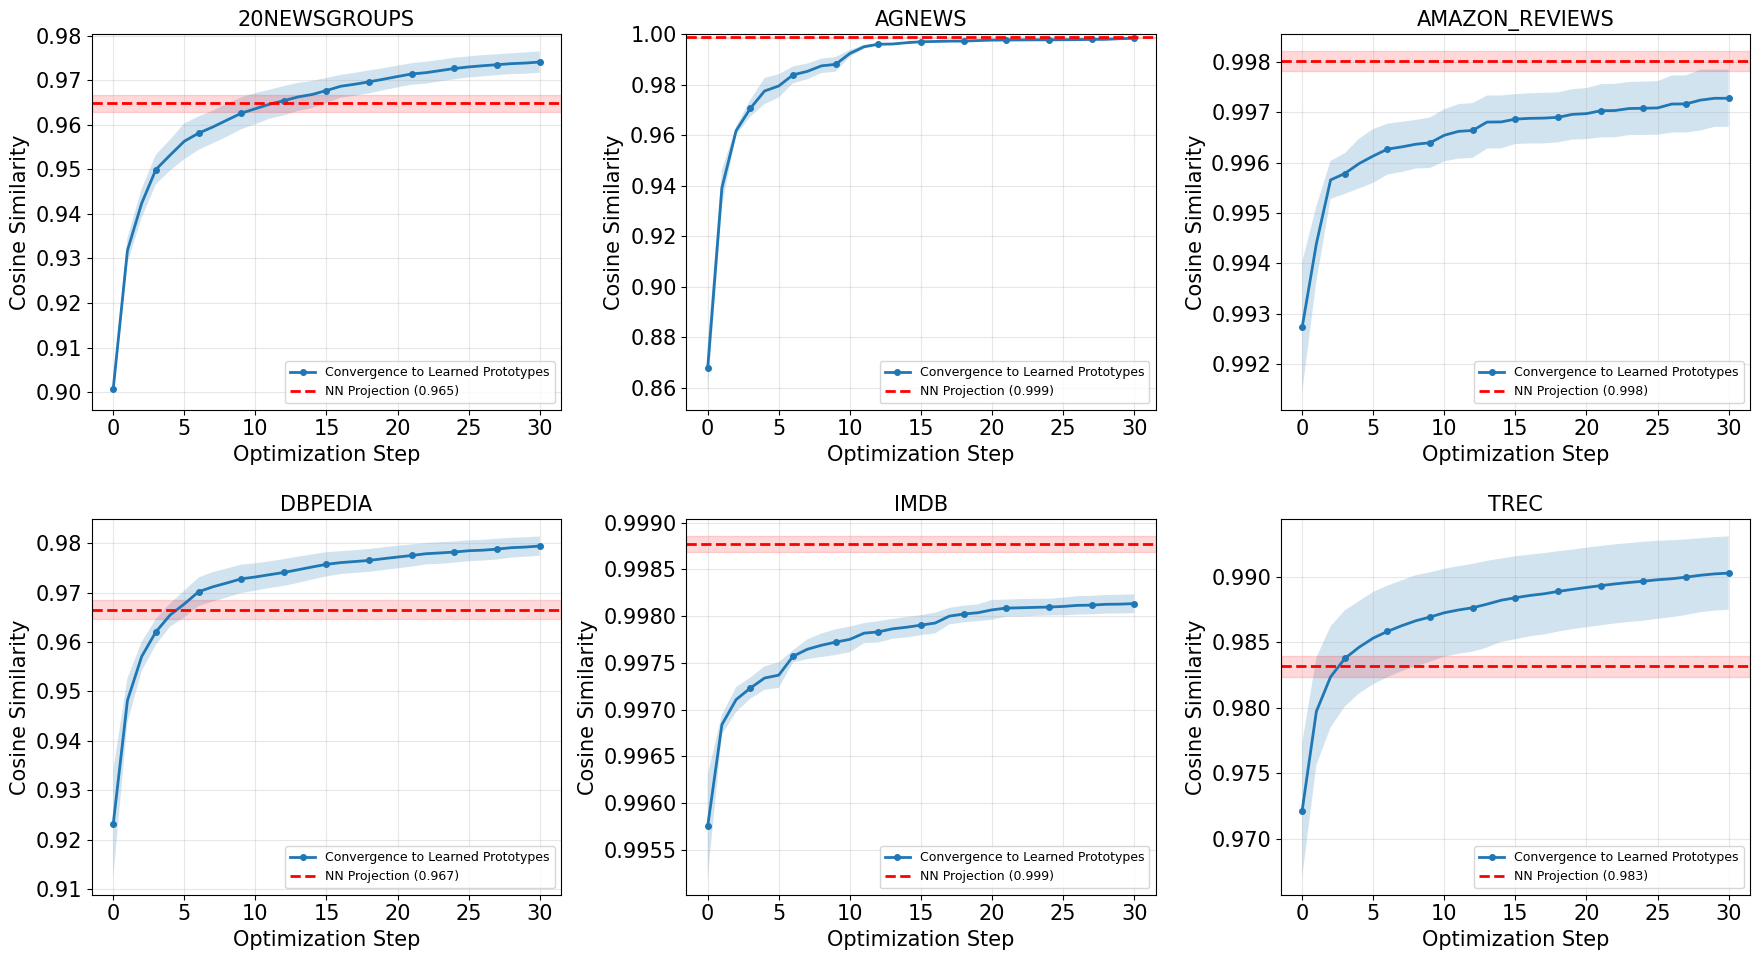


CREATING ALL COMBINATIONS PLOTS

Processing 20newsgroups-bert...
  ✓ Found 3 seeds with data

Processing 20newsgroups-electra...
  ✓ Found 3 seeds with data

Processing 20newsgroups-modern_bert...
  ✓ Found 3 seeds with data

Processing 20newsgroups-mpnet...
  ✓ Found 3 seeds with data

Processing 20newsgroups-roberta...
  ✓ Found 3 seeds with data

Processing agnews-bert...
  ✓ Found 3 seeds with data

Processing agnews-electra...
  ✓ Found 3 seeds with data

Processing agnews-modern_bert...
  ✓ Found 3 seeds with data

Processing agnews-mpnet...
  ✓ Found 3 seeds with data

Processing agnews-roberta...
  ✓ Found 3 seeds with data

Processing amazon_reviews-bert...
  ✓ Found 3 seeds with data

Processing amazon_reviews-electra...
  ✓ Found 3 seeds with data

Processing amazon_reviews-modern_bert...
  ✓ Found 3 seeds with data

Processing amazon_reviews-mpnet...
  ✓ Found 3 seeds with data

Processing amazon_reviews-roberta...
  ✓ Found 3 seeds with data

Processing dbpedia-bert...
  

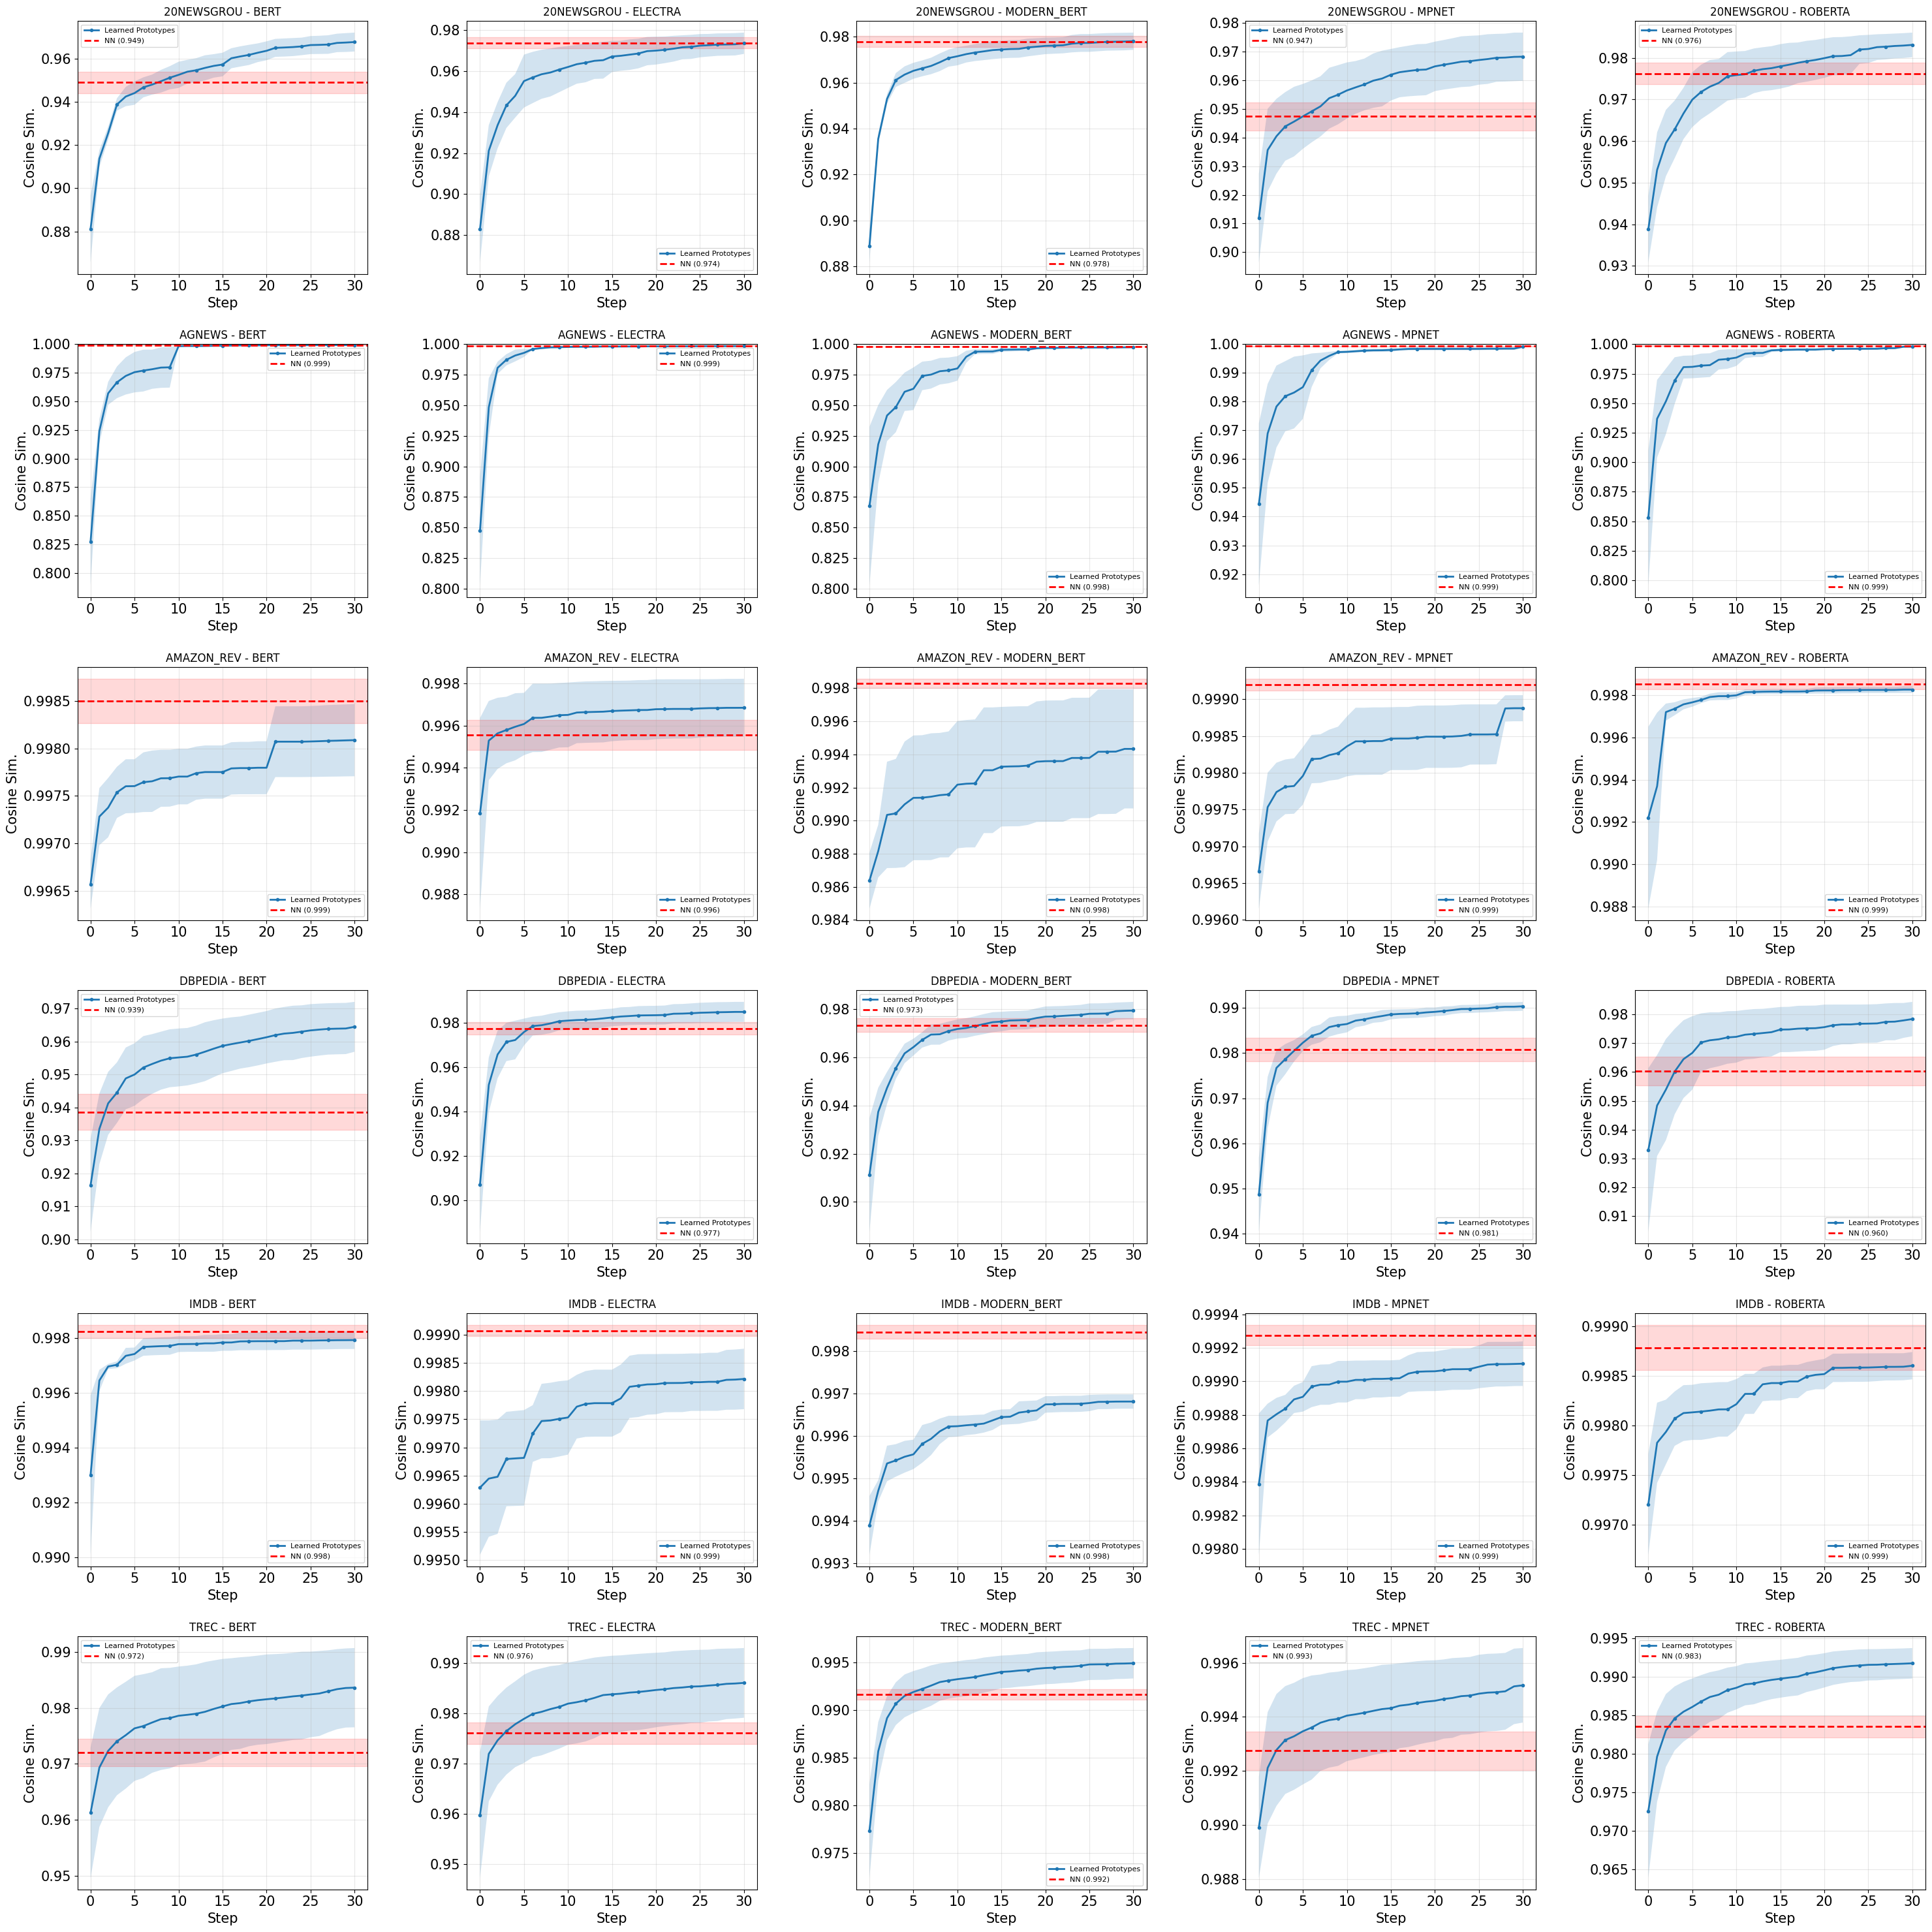


PLOTTING COMPLETE


In [40]:
#!/usr/bin/env python3
"""
Robust multi-seed plotting script showing optimization convergence across multiple seeds.
Automatically detects available datasets and models from the data.
Plots mean ± standard error across seeds for cosine similarities.
"""

import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import defaultdict

# Make all fonts roughly double size
plt.rcParams.update({
    "font.size": 20,          # base font size
    "axes.titlesize": 15,     # subplot titles
    "axes.labelsize": 15,     # x and y labels
    "xtick.labelsize": 15,    # x tick labels
    "ytick.labelsize": 15,    # y tick labels
    "legend.fontsize": 10     # legend
})

# # Configuration
SEEDS = [0,1,2]
DATASETS = ['imdb', 'amazon_reviews', 'agnews', '20newsgroups', 'dbpedia', 'trec']
MODELS = ['mpnet', 'modern_bert', 'bert', 'roberta', 'electra']

EXPECTED_DATASETS = DATASETS
EXPECTED_MODELS = MODELS


def load_all_seed_data(seeds):
    """Load data for all available seeds and detect what's available"""
    all_data_by_seed = {}
    available_seeds = []
    available_datasets = set()
    available_models = set()
    
    print("=" * 60)
    print("LOADING DATA")
    print("=" * 60)
    
    for seed in seeds:
        try:
            filepath = f'data/optimization_exp_all_data_seed{seed}.pickle'
            with open(filepath, 'rb') as handle:
                data = pickle.load(handle)
                all_data_by_seed[seed] = data
                available_seeds.append(seed)
                print(f"✓ Loaded data for seed {seed}")
                
                # Detect available datasets and models from keys
                for key in data.keys():
                    if '_latent_optim_3llms' in key:
                        # Remove the suffix
                        prefix = key.replace('_latent_optim_3llms', '')
                        
                        # Try to match against known models (longest first to handle models with underscores)
                        matched = False
                        for model in sorted(EXPECTED_MODELS, key=len, reverse=True):
                            if prefix.endswith('_' + model):
                                dataset = prefix[:-(len(model) + 1)]
                                available_datasets.add(dataset)
                                available_models.add(model)
                                matched = True
                                break
                        
                        # If no expected model matched, fall back to original logic
                        if not matched:
                            parts = prefix.rsplit('_', 1)
                            if len(parts) == 2:
                                dataset, model = parts
                                available_datasets.add(dataset)
                                available_models.add(model)
                
        except FileNotFoundError:
            print(f"✗ Data file for seed {seed} not found")
            continue
        except Exception as e:
            print(f"✗ Error loading seed {seed}: {e}")
            continue
        
    if not all_data_by_seed:
        print("\n⚠️  NO DATA FILES FOUND!")
        print(f"Looked for files matching: data/optimization_exp_all_data_seed[N].pickle")
        return None, None, None, None
    
    # Filter to only expected datasets/models if they exist
    final_datasets = sorted([d for d in available_datasets if d in EXPECTED_DATASETS])
    final_models = sorted([m for m in available_models if m in EXPECTED_MODELS])
    
    # If no expected datasets found, use all available
    if not final_datasets:
        final_datasets = sorted(available_datasets)
    if not final_models:
        final_models = sorted(available_models)
    
    print(f"\nAvailable seeds: {available_seeds}")
    print(f"Available datasets: {final_datasets}")
    print(f"Available models: {final_models}")
    
    return all_data_by_seed, available_seeds, final_datasets, final_models

def get_subplot_layout(n_items, aspect_ratio=1.5):
    """Determine optimal subplot layout for n items"""
    if n_items <= 3:
        return 1, n_items
    elif n_items <= 6:
        return 2, 3
    elif n_items <= 9:
        return 3, 3
    elif n_items <= 12:
        return 3, 4
    elif n_items <= 16:
        return 4, 4
    else:
        cols = int(np.ceil(np.sqrt(n_items * aspect_ratio)))
        rows = int(np.ceil(n_items / cols))
        return rows, cols

def create_averaged_plots(all_data_by_seed, available_seeds, datasets, models):
    """Create plots averaged across models (one subplot for each dataset)"""
    
    print("\n" + "=" * 60)
    print("CREATING AVERAGED PLOTS (across models)")
    print("=" * 60)
    
    n_datasets = len(datasets)
    rows, cols = get_subplot_layout(n_datasets)
    
    # Create figure with appropriate size
    fig_width = 6 * cols
    fig_height = 5 * rows
    fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height))
    
    # Make axes always 2D for consistent indexing
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1 or cols == 1:
        axes = axes.reshape(rows, cols)
    
    os.makedirs('plots', exist_ok=True)
    
    plot_idx = 0
    for row in range(rows):
        for col in range(cols):
            ax = axes[row, col]
            
            if plot_idx >= n_datasets:
                # Hide extra subplots
                ax.set_visible(False)
                plot_idx += 1
                continue
            
            dataset = datasets[plot_idx]
            print(f"\nProcessing {dataset} (averaging across models)...")
            
            # Collect data across all models and seeds for this dataset
            all_early_distances = []
            all_optimization_curves = []
            
            for seed in available_seeds:
                all_data = all_data_by_seed[seed]
                
                # Collect curves for this seed across all models
                seed_curves = []
                seed_early_distances = []
                
                for model in models:
                    key = f'{dataset}_{model}_latent_optim_3llms'
                    
                    if key not in all_data or not all_data[key]:
                        continue
                    
                    experiment_data = all_data[key]
                    
                    try:
                        # Extract data with error handling
                        early_distances = [float(proto.get('early_distance', 0)) 
                                         for proto in experiment_data 
                                         if 'early_distance' in proto]
                        histories = [list(map(float, proto['max_similarity'])) 
                                   for proto in experiment_data 
                                   if 'max_similarity' in proto]
                        
                        if not histories:
                            continue
                        
                        max_len = max(len(h) for h in histories)
                        padded = [h + [h[-1]] * (max_len - len(h)) for h in histories]
                        similarities_array = np.array(padded, dtype=float)
                        mean_for_seed_model = np.mean(similarities_array, axis=0)
                        
                        seed_curves.append(mean_for_seed_model)
                        seed_early_distances.extend(early_distances)
                        
                    except Exception as e:
                        print(f"  Error processing {dataset}-{model} seed {seed}: {e}")
                        continue
                
                if seed_curves:
                    min_len = min(len(curve) for curve in seed_curves)
                    truncated_curves = [curve[:min_len] for curve in seed_curves]
                    seed_avg_curve = np.mean(truncated_curves, axis=0)
                    
                    all_optimization_curves.append(seed_avg_curve)
                    all_early_distances.extend(seed_early_distances)
            
            if not all_optimization_curves:
                ax.text(0.5, 0.5, f'No data\n{dataset}', 
                        ha='center', va='center', transform=ax.transAxes,
                        fontsize=12)
                ax.set_title(f'{dataset.upper()}')
                ax.set_xlabel('Iteration')
                ax.set_ylabel('Cosine Similarity')
                ax.set_xlim(0, 10)
                ax.set_ylim(0, 1)
                plot_idx += 1
                continue
            
            # Find common length for curves
            min_len = min(len(curve) for curve in all_optimization_curves)
            truncated_curves = [curve[:min_len] for curve in all_optimization_curves]
            curves_array = np.array(truncated_curves)
            
            mean_across_seeds = np.mean(curves_array, axis=0)
            std_across_seeds = np.std(curves_array, axis=0, ddof=1) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
            sem_across_seeds = std_across_seeds / np.sqrt(len(curves_array)) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
            
            iterations = np.arange(min_len)
            
            # Early baseline
            if all_early_distances:
                early_mean = float(np.mean(all_early_distances))
                early_std = float(np.std(all_early_distances, ddof=1)) if len(all_early_distances) > 1 else 0.0
                early_sem = early_std / np.sqrt(len(all_early_distances)) if len(all_early_distances) > 1 else 0.0
            else:
                early_mean = early_std = early_sem = 0.0
            
            # Plot
            ax.plot(iterations, mean_across_seeds, linewidth=2, 
                    label=f'Convergence to Learned Prototypes', 
                    marker='o', markersize=4, markevery=max(1, len(iterations)//10))
            ax.fill_between(iterations, 
                            mean_across_seeds - sem_across_seeds,
                            mean_across_seeds + sem_across_seeds,
                            alpha=0.2)
            
            if early_mean > 0:
                ax.axhline(y=early_mean, linestyle='--', linewidth=2, color='red',
                           label=f'NN Projection ({early_mean:.3f})')
                ax.axhspan(early_mean - early_sem, early_mean + early_sem, 
                           alpha=0.15, color='red')
            
            ax.set_xlabel('Optimization Step')
            ax.set_ylabel('Cosine Similarity')
            ax.set_title(f'{dataset.upper()}')
            
            ax.legend(fontsize=9, loc='best')
            ax.grid(True, alpha=0.3)
            
            # Dynamic y-axis scaling
            ymin = min(np.min(mean_across_seeds - sem_across_seeds), 
                      early_mean - early_sem if early_mean > 0 else np.min(mean_across_seeds))
            ymax = max(np.max(mean_across_seeds + sem_across_seeds), 
                      early_mean + early_sem if early_mean > 0 else np.max(mean_across_seeds))
            pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
            ax.set_ylim(max(0, ymin - pad), min(1, ymax + pad))
            
            print(f"  ✓ Plotted {dataset}: {len(all_optimization_curves)} seed-model combinations")
            plot_idx += 1
    
    plt.tight_layout()
    
    plot_path = f'plots/convergence_averaged_{n_datasets}datasets.pdf'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nSaved averaged plot to: {plot_path}")
    plt.show()

def create_all_combinations_plots(all_data_by_seed, available_seeds, datasets, models):
    """Create plots showing all dataset-model combinations"""
    
    print("\n" + "=" * 60)
    print("CREATING ALL COMBINATIONS PLOTS")
    print("=" * 60)
    
    n_datasets = len(datasets)
    n_models = len(models)
    
    # Create figure with dataset rows and model columns
    fig_width = 6 * n_models
    fig_height = 5 * n_datasets
    fig, axes = plt.subplots(n_datasets, n_models, figsize=(fig_width, fig_height))
    
    # Make axes always 2D for consistent indexing
    if n_datasets == 1 and n_models == 1:
        axes = np.array([[axes]])
    elif n_datasets == 1:
        axes = axes.reshape(1, n_models)
    elif n_models == 1:
        axes = axes.reshape(n_datasets, 1)
    
    os.makedirs('plots', exist_ok=True)
    
    data_found_count = 0
    
    for i, dataset in enumerate(datasets):
        for j, model in enumerate(models):
            ax = axes[i, j]
            
            print(f"\nProcessing {dataset}-{model}...")
            
            all_early_distances = []
            all_optimization_curves = []
            
            for seed in available_seeds:
                key = f'{dataset}_{model}_latent_optim_3llms'
                all_data = all_data_by_seed[seed]
                
                if key not in all_data or not all_data[key]:
                    continue
                
                experiment_data = all_data[key]
                
                try:
                    early_distances = [float(proto.get('early_distance', 0)) 
                                     for proto in experiment_data 
                                     if 'early_distance' in proto]
                    histories = [list(map(float, proto['max_similarity'])) 
                               for proto in experiment_data 
                               if 'max_similarity' in proto]
                    
                    if not histories:
                        continue
                    
                    max_len = max(len(h) for h in histories)
                    padded = [h + [h[-1]] * (max_len - len(h)) for h in histories]
                    similarities_array = np.array(padded, dtype=float)
                    mean_for_seed = np.mean(similarities_array, axis=0)
                    
                    all_early_distances.extend(early_distances)
                    all_optimization_curves.append(mean_for_seed)
                    
                except Exception as e:
                    print(f"  Error processing seed {seed}: {e}")
                    continue
            
            if not all_optimization_curves:
                ax.text(0.5, 0.5, f'No data\n{dataset}-{model}', 
                        ha='center', va='center', transform=ax.transAxes,
                        fontsize=10)
                ax.set_title(f'{dataset.upper()} - {model.upper()}')
                ax.set_xlabel('Optimization Step')
                ax.set_ylabel('Cosine Similarity')
                ax.set_xlim(0, 10)
                ax.set_ylim(0, 1)
                continue
            
            data_found_count += 1
            
            min_len = min(len(curve) for curve in all_optimization_curves)
            truncated_curves = [curve[:min_len] for curve in all_optimization_curves]
            curves_array = np.array(truncated_curves)
            
            mean_across_seeds = np.mean(curves_array, axis=0)
            std_across_seeds = np.std(curves_array, axis=0, ddof=1) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
            sem_across_seeds = std_across_seeds / np.sqrt(len(curves_array)) if len(curves_array) > 1 else np.zeros_like(mean_across_seeds)
            
            iterations = np.arange(min_len)
            
            if all_early_distances:
                early_mean = float(np.mean(all_early_distances))
                early_std = float(np.std(all_early_distances, ddof=1)) if len(all_early_distances) > 1 else 0.0
                early_sem = early_std / np.sqrt(len(all_early_distances)) if len(all_early_distances) > 1 else 0.0
            else:
                early_mean = early_std = early_sem = 0.0
            
            ax.plot(iterations, mean_across_seeds, linewidth=2, 
                    label=f'Learned Prototypes', 
                    marker='o', markersize=3, markevery=max(1, len(iterations)//10))
            ax.fill_between(iterations, 
                            mean_across_seeds - sem_across_seeds,
                            mean_across_seeds + sem_across_seeds,
                            alpha=0.2)
            
            if early_mean > 0:
                ax.axhline(y=early_mean, linestyle='--', linewidth=2, color='red',
                           label=f'NN ({early_mean:.3f})')
                ax.axhspan(early_mean - early_sem, early_mean + early_sem, 
                           alpha=0.15, color='red')
            
            ax.set_xlabel('Step')
            ax.set_ylabel('Cosine Sim.')
            ax.set_title(f'{dataset.upper()[:10]} - {model.upper()}', fontsize=12)
            
            ax.legend(fontsize=8, loc='best')
            ax.grid(True, alpha=0.3)

            # Dynamic y-axis scaling
            ymin = min(np.min(mean_across_seeds - sem_across_seeds), 
                      early_mean - early_sem if early_mean > 0 else np.min(mean_across_seeds))
            ymax = max(np.max(mean_across_seeds + sem_across_seeds), 
                      early_mean + early_sem if early_mean > 0 else np.max(mean_across_seeds))
            pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
            ax.set_ylim(max(0, ymin - pad), min(1, ymax + pad))
            
            print(f"  ✓ Found {len(all_optimization_curves)} seeds with data")
    
    plt.tight_layout()
    
    plot_path = f'plots/convergence_all_{n_datasets}x{n_models}.pdf'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nSaved all combinations plot to: {plot_path}")
    print(f"Total plots with data: {data_found_count}/{n_datasets * n_models}")
    plt.show()

def main():
    """Main function to create all plots"""
    print("=" * 60)
    print("MULTI-SEED CONVERGENCE PLOTTING")
    print("=" * 60)
    print(f"Attempting to load seeds: {SEEDS}")
    
    # Load all available data
    all_data_by_seed, available_seeds, datasets, models = load_all_seed_data(SEEDS)
    
    if all_data_by_seed is None:
        print("\n⚠️  Cannot proceed without data. Exiting.")
        return
    
    if not datasets or not models:
        print("\n⚠️  No valid datasets or models found in data. Exiting.")
        return
    
    print(f"\nWill create plots for:")
    print(f"  - {len(datasets)} datasets: {datasets}")
    print(f"  - {len(models)} models: {models}")
    print(f"  - {len(available_seeds)} seeds: {available_seeds}")
    
    # Create averaged plots (across models)
    try:
        create_averaged_plots(all_data_by_seed, available_seeds, datasets, models)
    except Exception as e:
        print(f"\n⚠️  Error creating averaged plots: {e}")
        import traceback
        traceback.print_exc()
    
    # Create all combinations plots
    try:
        create_all_combinations_plots(all_data_by_seed, available_seeds, datasets, models)
    except Exception as e:
        print(f"\n⚠️  Error creating all combinations plots: {e}")
        import traceback
        traceback.print_exc()
    
    print("\n" + "=" * 60)
    print("PLOTTING COMPLETE")
    print("=" * 60)

if __name__ == "__main__":
    main()

In [41]:
#!/usr/bin/env python3
"""
Extract and display summary results from the experiment data in table format.
Shows accuracy metrics, precision, recall, F1 scores, and cosine similarity measurements across multiple seeds.
Reports mean ± standard error for each metric.
Includes statistical significance testing between Stage A and Stage B results.
Automatically detects available datasets and models from the data.
"""

import pickle
import pandas as pd
import numpy as np
from scipy import stats

# Configuration - same as plotting script
SEEDS = [0, 1, 2]
EXPECTED_DATASETS = ['imdb', 'amazon_reviews', 'agnews', '20newsgroups', 'dbpedia', 'trec']
EXPECTED_MODELS = ['mpnet', 'modern_bert', 'bert', 'roberta', 'electra']


def load_all_seed_data(seeds):
    """Load data for all available seeds and detect what's available"""
    all_data_by_seed = {}
    available_seeds = []
    available_datasets = set()
    available_models = set()
    
    print("=" * 60)
    print("LOADING DATA")
    print("=" * 60)
    
    for seed in seeds:
        try:
            filepath = f'data/optimization_exp_all_data_seed{seed}.pickle'
            with open(filepath, 'rb') as handle:
                data = pickle.load(handle)
                all_data_by_seed[seed] = data
                available_seeds.append(seed)
                print(f"✓ Loaded data for seed {seed}")
                
                # Detect available datasets and models from keys
                for key in data.keys():
                    if '_latent_optim_3llms' in key:
                        # Remove the suffix
                        prefix = key.replace('_latent_optim_3llms_summary', '').replace('_latent_optim_3llms', '')
                        
                        # Try to match against known models (longest first to handle models with underscores)
                        matched = False
                        for model in sorted(EXPECTED_MODELS, key=len, reverse=True):
                            if prefix.endswith('_' + model):
                                dataset = prefix[:-(len(model) + 1)]
                                available_datasets.add(dataset)
                                available_models.add(model)
                                matched = True
                                break
                        
                        # If no expected model matched, fall back to original logic
                        if not matched:
                            parts = prefix.rsplit('_', 1)
                            if len(parts) == 2:
                                dataset, model = parts
                                available_datasets.add(dataset)
                                available_models.add(model)
                
        except FileNotFoundError:
            print(f"✗ Data file for seed {seed} not found")
            continue
        except Exception as e:
            print(f"✗ Error loading seed {seed}: {e}")
            continue
        
    if not all_data_by_seed:
        print("\n⚠️  NO DATA FILES FOUND!")
        print(f"Looked for files matching: data/optimization_exp_all_data_seed[N].pickle")
        return None, None, None, None
    
    # Filter to only expected datasets/models if they exist
    final_datasets = sorted([d for d in available_datasets if d in EXPECTED_DATASETS])
    final_models = sorted([m for m in available_models if m in EXPECTED_MODELS])
    
    # If no expected datasets found, use all available
    if not final_datasets:
        final_datasets = sorted(available_datasets)
    if not final_models:
        final_models = sorted(available_models)
    
    print(f"\nAvailable seeds: {available_seeds}")
    print(f"Available datasets: {final_datasets}")
    print(f"Available models: {final_models}")
    
    return all_data_by_seed, available_seeds, final_datasets, final_models


def extract_summary_data(all_data_by_seed, available_seeds, datasets, models):
    """Extract summary statistics across all available seeds"""
    
    results = []
    
    for dataset in datasets:
        for model in models:
            # Collect metrics across all available seeds for this dataset/model combination
            metrics_across_seeds = {
                'base_acc': [],
                'stageA_acc': [],
                'stageB_acc': [],
                'base_f1': [],
                'stageA_f1': [],
                'stageB_f1': [],
                'base_precision': [],
                'stageA_precision': [],
                'stageB_precision': [],
                'base_recall': [],
                'stageA_recall': [],
                'stageB_recall': [],
                'cos_proto_to_train': [],
                'cos_optimized_to_proto': []
            }
            
            for seed in available_seeds:
                if seed not in all_data_by_seed:
                    continue
                
                all_data = all_data_by_seed[seed]
                summary_key = f'{dataset}_{model}_latent_optim_3llms_summary'
                
                if summary_key in all_data:
                    summary = all_data[summary_key]
                    
                    # Extract accuracy metrics
                    base_acc = summary.get('base_metrics', {}).get('accuracy', None)
                    if base_acc is not None:
                        metrics_across_seeds['base_acc'].append(base_acc)
                    
                    stageA_acc = summary.get('stageA_metrics_optimized_text_latents', {}).get('accuracy', None)
                    if stageA_acc is not None:
                        metrics_across_seeds['stageA_acc'].append(stageA_acc)
                    
                    stageB_acc = summary.get('stageB_metrics_projected', {}).get('accuracy', None)
                    if stageB_acc is not None:
                        metrics_across_seeds['stageB_acc'].append(stageB_acc)
                    
                    # Extract F1 scores
                    base_f1 = summary.get('base_metrics', {}).get('macro', {}).get('f1', None)
                    if base_f1 is not None:
                        metrics_across_seeds['base_f1'].append(base_f1)
                    
                    stageA_f1 = summary.get('stageA_metrics_optimized_text_latents', {}).get('macro', {}).get('f1', None)
                    if stageA_f1 is not None:
                        metrics_across_seeds['stageA_f1'].append(stageA_f1)
                    
                    stageB_f1 = summary.get('stageB_metrics_projected', {}).get('macro', {}).get('f1', None)
                    if stageB_f1 is not None:
                        metrics_across_seeds['stageB_f1'].append(stageB_f1)
                    
                    # Extract precision scores
                    base_precision = summary.get('base_metrics', {}).get('macro', {}).get('precision', None)
                    if base_precision is not None:
                        metrics_across_seeds['base_precision'].append(base_precision)
                    
                    stageA_precision = summary.get('stageA_metrics_optimized_text_latents', {}).get('macro', {}).get('precision', None)
                    if stageA_precision is not None:
                        metrics_across_seeds['stageA_precision'].append(stageA_precision)
                    
                    stageB_precision = summary.get('stageB_metrics_projected', {}).get('macro', {}).get('precision', None)
                    if stageB_precision is not None:
                        metrics_across_seeds['stageB_precision'].append(stageB_precision)
                    
                    # Extract recall scores
                    base_recall = summary.get('base_metrics', {}).get('macro', {}).get('recall', None)
                    if base_recall is not None:
                        metrics_across_seeds['base_recall'].append(base_recall)
                    
                    stageA_recall = summary.get('stageA_metrics_optimized_text_latents', {}).get('macro', {}).get('recall', None)
                    if stageA_recall is not None:
                        metrics_across_seeds['stageA_recall'].append(stageA_recall)
                    
                    stageB_recall = summary.get('stageB_metrics_projected', {}).get('macro', {}).get('recall', None)
                    if stageB_recall is not None:
                        metrics_across_seeds['stageB_recall'].append(stageB_recall)
                    
                    # Extract cosine similarity metrics
                    cos_proto_to_train = summary.get('avg_cosine_proto_to_nearest_train', None)
                    if cos_proto_to_train is not None:
                        metrics_across_seeds['cos_proto_to_train'].append(cos_proto_to_train)
                    
                    cos_optimized_to_proto = summary.get('avg_cosine_optimized_to_proto', None)
                    if cos_optimized_to_proto is not None:
                        metrics_across_seeds['cos_optimized_to_proto'].append(cos_optimized_to_proto)
            
            # Skip this combination if no data was found
            if not any(len(v) > 0 for v in metrics_across_seeds.values()):
                continue
            
            # Compute mean and standard error for each metric
            def compute_stats(values):
                if len(values) == 0:
                    return None, None, 0
                elif len(values) == 1:
                    return values[0], 0.0, 1
                else:
                    mean = np.mean(values)
                    std_err = np.std(values, ddof=1) / np.sqrt(len(values))
                    return mean, std_err, len(values)
            
            # Apply to all metrics
            base_acc_mean, base_acc_se, base_acc_n = compute_stats(metrics_across_seeds['base_acc'])
            stageA_acc_mean, stageA_acc_se, stageA_acc_n = compute_stats(metrics_across_seeds['stageA_acc'])
            stageB_acc_mean, stageB_acc_se, stageB_acc_n = compute_stats(metrics_across_seeds['stageB_acc'])
            
            base_f1_mean, base_f1_se, base_f1_n = compute_stats(metrics_across_seeds['base_f1'])
            stageA_f1_mean, stageA_f1_se, stageA_f1_n = compute_stats(metrics_across_seeds['stageA_f1'])
            stageB_f1_mean, stageB_f1_se, stageB_f1_n = compute_stats(metrics_across_seeds['stageB_f1'])
            
            base_precision_mean, base_precision_se, base_precision_n = compute_stats(metrics_across_seeds['base_precision'])
            stageA_precision_mean, stageA_precision_se, stageA_precision_n = compute_stats(metrics_across_seeds['stageA_precision'])
            stageB_precision_mean, stageB_precision_se, stageB_precision_n = compute_stats(metrics_across_seeds['stageB_precision'])
            
            base_recall_mean, base_recall_se, base_recall_n = compute_stats(metrics_across_seeds['base_recall'])
            stageA_recall_mean, stageA_recall_se, stageA_recall_n = compute_stats(metrics_across_seeds['stageA_recall'])
            stageB_recall_mean, stageB_recall_se, stageB_recall_n = compute_stats(metrics_across_seeds['stageB_recall'])
            
            cos_proto_mean, cos_proto_se, cos_proto_n = compute_stats(metrics_across_seeds['cos_proto_to_train'])
            cos_opt_mean, cos_opt_se, cos_opt_n = compute_stats(metrics_across_seeds['cos_optimized_to_proto'])
            
            # Statistical significance test between Stage A and Stage B accuracies
            pvalue_acc_A_vs_B = None
            if (len(metrics_across_seeds['stageA_acc']) >= 2 and 
                len(metrics_across_seeds['stageB_acc']) >= 2 and
                len(metrics_across_seeds['stageA_acc']) == len(metrics_across_seeds['stageB_acc'])):
                try:
                    # Paired t-test between Stage A and Stage B accuracies
                    stat, p_val = stats.ttest_rel(metrics_across_seeds['stageA_acc'], 
                                                  metrics_across_seeds['stageB_acc'])
                    pvalue_acc_A_vs_B = p_val
                except:
                    pvalue_acc_A_vs_B = None
            
            results.append({
                'Dataset': dataset.upper(),
                'Model': model.upper(),
                'Base_Acc_Mean': base_acc_mean,
                'Base_Acc_SE': base_acc_se,
                'Base_Acc_N': base_acc_n,
                'StageA_Acc_Mean': stageA_acc_mean,
                'StageA_Acc_SE': stageA_acc_se,
                'StageA_Acc_N': stageA_acc_n,
                'StageB_Acc_Mean': stageB_acc_mean,
                'StageB_Acc_SE': stageB_acc_se,
                'StageB_Acc_N': stageB_acc_n,
                'PValue_A_vs_B_Acc': pvalue_acc_A_vs_B,
                'Base_F1_Mean': base_f1_mean,
                'Base_F1_SE': base_f1_se,
                'StageA_F1_Mean': stageA_f1_mean,
                'StageA_F1_SE': stageA_f1_se,
                'StageB_F1_Mean': stageB_f1_mean,
                'StageB_F1_SE': stageB_f1_se,
                'Base_Precision_Mean': base_precision_mean,
                'Base_Precision_SE': base_precision_se,
                'StageA_Precision_Mean': stageA_precision_mean,
                'StageA_Precision_SE': stageA_precision_se,
                'StageB_Precision_Mean': stageB_precision_mean,
                'StageB_Precision_SE': stageB_precision_se,
                'Base_Recall_Mean': base_recall_mean,
                'Base_Recall_SE': base_recall_se,
                'StageA_Recall_Mean': stageA_recall_mean,
                'StageA_Recall_SE': stageA_recall_se,
                'StageB_Recall_Mean': stageB_recall_mean,
                'StageB_Recall_SE': stageB_recall_se,
                'Cos_Proto_Mean': cos_proto_mean,
                'Cos_Proto_SE': cos_proto_se,
                'Cos_Opt_Mean': cos_opt_mean,
                'Cos_Opt_SE': cos_opt_se,
            })
    
    return results


def format_mean_se(mean, se, n):
    """Format mean ± standard error with sample size"""
    if mean is None:
        return "N/A"
    elif se is None or se == 0:
        return f"{mean:.4f} (n={n})"
    else:
        return f"{mean:.4f}±{se:.4f} (n={n})"


def format_pvalue(pvalue):
    """Format p-value with appropriate precision"""
    if pvalue is None:
        return "N/A"
    elif pvalue < 0.001:
        return "<0.001"
    else:
        return f"{pvalue:.3f}"


def print_quick_summaries(results):
    """Print quick summary statistics for specific dataset groups"""
    
    if not results:
        return
    
    df = pd.DataFrame(results)
    
    print("\n" + "=" * 80)
    print("QUICK SUMMARY STATISTICS")
    print("=" * 80)
    
    # Group 1: ['imdb', 'amazon_reviews', 'agnews']
    group1_datasets = ['IMDB', 'AMAZON_REVIEWS', 'AGNEWS']
    group1_data = df[df['Dataset'].isin(group1_datasets)]
    
    if len(group1_data) > 0:
        print("\n1. DATASETS: IMDB, Amazon Reviews, AGNews")
        print("-" * 80)
        
        # Calculate deltas for ACCURACY (Stage A - Base, Stage B - Base)
        deltas_a_acc = []
        deltas_b_acc = []
        
        for _, row in group1_data.iterrows():
            if row['Base_Acc_Mean'] is not None and row['StageA_Acc_Mean'] is not None:
                deltas_a_acc.append(row['StageA_Acc_Mean'] - row['Base_Acc_Mean'])
            if row['Base_Acc_Mean'] is not None and row['StageB_Acc_Mean'] is not None:
                deltas_b_acc.append(row['StageB_Acc_Mean'] - row['Base_Acc_Mean'])
        
        print("   ACCURACY:")
        if deltas_a_acc:
            avg_delta_a = np.mean(deltas_a_acc)
            se_delta_a = np.std(deltas_a_acc, ddof=1) / np.sqrt(len(deltas_a_acc)) if len(deltas_a_acc) > 1 else 0.0
            print(f"      Average Δ(Stage A - Base): {avg_delta_a:+.4f} ± {se_delta_a:.4f} (n={len(deltas_a_acc)})")
        else:
            print(f"      Average Δ(Stage A - Base): N/A")
        
        if deltas_b_acc:
            avg_delta_b = np.mean(deltas_b_acc)
            se_delta_b = np.std(deltas_b_acc, ddof=1) / np.sqrt(len(deltas_b_acc)) if len(deltas_b_acc) > 1 else 0.0
            print(f"      Average Δ(Stage B - Base): {avg_delta_b:+.4f} ± {se_delta_b:.4f} (n={len(deltas_b_acc)})")
        else:
            print(f"      Average Δ(Stage B - Base): N/A")
        
        # Calculate deltas for F1 SCORE (Stage A - Base, Stage B - Base)
        deltas_a_f1 = []
        deltas_b_f1 = []
        
        for _, row in group1_data.iterrows():
            if row['Base_F1_Mean'] is not None and row['StageA_F1_Mean'] is not None:
                deltas_a_f1.append(row['StageA_F1_Mean'] - row['Base_F1_Mean'])
            if row['Base_F1_Mean'] is not None and row['StageB_F1_Mean'] is not None:
                deltas_b_f1.append(row['StageB_F1_Mean'] - row['Base_F1_Mean'])
        
        print("   F1 SCORE:")
        if deltas_a_f1:
            avg_delta_a = np.mean(deltas_a_f1)
            se_delta_a = np.std(deltas_a_f1, ddof=1) / np.sqrt(len(deltas_a_f1)) if len(deltas_a_f1) > 1 else 0.0
            print(f"      Average Δ(Stage A - Base): {avg_delta_a:+.4f} ± {se_delta_a:.4f} (n={len(deltas_a_f1)})")
        else:
            print(f"      Average Δ(Stage A - Base): N/A")
        
        if deltas_b_f1:
            avg_delta_b = np.mean(deltas_b_f1)
            se_delta_b = np.std(deltas_b_f1, ddof=1) / np.sqrt(len(deltas_b_f1)) if len(deltas_b_f1) > 1 else 0.0
            print(f"      Average Δ(Stage B - Base): {avg_delta_b:+.4f} ± {se_delta_b:.4f} (n={len(deltas_b_f1)})")
        else:
            print(f"      Average Δ(Stage B - Base): N/A")
    else:
        print("\n1. DATASETS: IMDB, Amazon Reviews, AGNews")
        print("-" * 80)
        print("   No data found for this group")
    
    # Group 2: ['trec', '20newsgroups', 'dbpedia']
    group2_datasets = ['TREC', '20NEWSGROUPS', 'DBPEDIA']
    group2_data = df[df['Dataset'].isin(group2_datasets)]
    
    if len(group2_data) > 0:
        print("\n2. DATASETS: TREC, 20NewsGroups, DBpedia")
        print("-" * 80)
        
        # Calculate deltas for ACCURACY (Stage A - Base, Stage B - Base)
        deltas_a_acc = []
        deltas_b_acc = []
        
        for _, row in group2_data.iterrows():
            if row['Base_Acc_Mean'] is not None and row['StageA_Acc_Mean'] is not None:
                deltas_a_acc.append(row['StageA_Acc_Mean'] - row['Base_Acc_Mean'])
            if row['Base_Acc_Mean'] is not None and row['StageB_Acc_Mean'] is not None:
                deltas_b_acc.append(row['StageB_Acc_Mean'] - row['Base_Acc_Mean'])
        
        print("   ACCURACY:")
        if deltas_a_acc:
            avg_delta_a = np.mean(deltas_a_acc)
            se_delta_a = np.std(deltas_a_acc, ddof=1) / np.sqrt(len(deltas_a_acc)) if len(deltas_a_acc) > 1 else 0.0
            print(f"      Average Δ(Stage A - Base): {avg_delta_a:+.4f} ± {se_delta_a:.4f} (n={len(deltas_a_acc)})")
        else:
            print(f"      Average Δ(Stage A - Base): N/A")
        
        if deltas_b_acc:
            avg_delta_b = np.mean(deltas_b_acc)
            se_delta_b = np.std(deltas_b_acc, ddof=1) / np.sqrt(len(deltas_b_acc)) if len(deltas_b_acc) > 1 else 0.0
            print(f"      Average Δ(Stage B - Base): {avg_delta_b:+.4f} ± {se_delta_b:.4f} (n={len(deltas_b_acc)})")
        else:
            print(f"      Average Δ(Stage B - Base): N/A")
        
        # Calculate deltas for F1 SCORE (Stage A - Base, Stage B - Base)
        deltas_a_f1 = []
        deltas_b_f1 = []
        
        for _, row in group2_data.iterrows():
            if row['Base_F1_Mean'] is not None and row['StageA_F1_Mean'] is not None:
                deltas_a_f1.append(row['StageA_F1_Mean'] - row['Base_F1_Mean'])
            if row['Base_F1_Mean'] is not None and row['StageB_F1_Mean'] is not None:
                deltas_b_f1.append(row['StageB_F1_Mean'] - row['Base_F1_Mean'])
        
        print("   F1 SCORE:")
        if deltas_a_f1:
            avg_delta_a = np.mean(deltas_a_f1)
            se_delta_a = np.std(deltas_a_f1, ddof=1) / np.sqrt(len(deltas_a_f1)) if len(deltas_a_f1) > 1 else 0.0
            print(f"      Average Δ(Stage A - Base): {avg_delta_a:+.4f} ± {se_delta_a:.4f} (n={len(deltas_a_f1)})")
        else:
            print(f"      Average Δ(Stage A - Base): N/A")
        
        if deltas_b_f1:
            avg_delta_b = np.mean(deltas_b_f1)
            se_delta_b = np.std(deltas_b_f1, ddof=1) / np.sqrt(len(deltas_b_f1)) if len(deltas_b_f1) > 1 else 0.0
            print(f"      Average Δ(Stage B - Base): {avg_delta_b:+.4f} ± {se_delta_b:.4f} (n={len(deltas_b_f1)})")
        else:
            print(f"      Average Δ(Stage B - Base): N/A")
    else:
        print("\n2. DATASETS: TREC, 20NewsGroups, DBpedia")
        print("-" * 80)
        print("   No data found for this group")
    
    # Group 2 comparisons
    if len(group2_data) > 0:
        print("\n3. COMPARISON COUNTS (TREC, 20NewsGroups, DBpedia)")
        print("-" * 80)
        
        # Count Stage A > Stage B for ACCURACY
        a_vs_b_count_acc = 0
        total_a_vs_b_acc = 0
        
        for _, row in group2_data.iterrows():
            if row['StageA_Acc_Mean'] is not None and row['StageB_Acc_Mean'] is not None:
                total_a_vs_b_acc += 1
                if row['StageA_Acc_Mean'] > row['StageB_Acc_Mean']:
                    a_vs_b_count_acc += 1
        
        print(f"   ACCURACY:")
        print(f"      Stage A > Stage B: {a_vs_b_count_acc}/{total_a_vs_b_acc} combinations")
        
        # Count Stage A > Base for ACCURACY
        a_vs_base_count_acc = 0
        total_a_vs_base_acc = 0
        
        for _, row in group2_data.iterrows():
            if row['Base_Acc_Mean'] is not None and row['StageA_Acc_Mean'] is not None:
                total_a_vs_base_acc += 1
                if row['StageA_Acc_Mean'] > row['Base_Acc_Mean']:
                    a_vs_base_count_acc += 1
        
        print(f"      Stage A > Base:    {a_vs_base_count_acc}/{total_a_vs_base_acc} combinations")
        
        # Count Stage A > Stage B for F1
        a_vs_b_count_f1 = 0
        total_a_vs_b_f1 = 0
        
        for _, row in group2_data.iterrows():
            if row['StageA_F1_Mean'] is not None and row['StageB_F1_Mean'] is not None:
                total_a_vs_b_f1 += 1
                if row['StageA_F1_Mean'] > row['StageB_F1_Mean']:
                    a_vs_b_count_f1 += 1
        
        print(f"   F1 SCORE:")
        print(f"      Stage A > Stage B: {a_vs_b_count_f1}/{total_a_vs_b_f1} combinations")
        
        # Count Stage A > Base for F1
        a_vs_base_count_f1 = 0
        total_a_vs_base_f1 = 0
        
        for _, row in group2_data.iterrows():
            if row['Base_F1_Mean'] is not None and row['StageA_F1_Mean'] is not None:
                total_a_vs_base_f1 += 1
                if row['StageA_F1_Mean'] > row['Base_F1_Mean']:
                    a_vs_base_count_f1 += 1
        
        print(f"      Stage A > Base:    {a_vs_base_count_f1}/{total_a_vs_base_f1} combinations")
    
    print("=" * 80 + "\n")


def display_results_table(results, available_seeds):
    """Display results in formatted tables"""
    
    if not results:
        print("⚠️  No results to display!")
        return None
    
    df = pd.DataFrame(results)
    
    print("="*160)
    print("EXPERIMENT RESULTS SUMMARY (Mean ± Standard Error)")
    print("="*160)
    
    print("\nACCURACY RESULTS")
    print("-" * 140)
    print(f"{'Dataset':<12} {'Model':<12} {'Base':<22} {'Stage A':<22} {'Stage B':<22} {'p-value (A vs B)':<15}")
    print("-" * 140)
    
    for _, row in df.iterrows():
        base_acc = format_mean_se(row['Base_Acc_Mean'], row['Base_Acc_SE'], row['Base_Acc_N'])
        stageA_acc = format_mean_se(row['StageA_Acc_Mean'], row['StageA_Acc_SE'], row['StageA_Acc_N'])
        stageB_acc = format_mean_se(row['StageB_Acc_Mean'], row['StageB_Acc_SE'], row['StageB_Acc_N'])
        pvalue = format_pvalue(row['PValue_A_vs_B_Acc'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<12} {base_acc:<22} {stageA_acc:<22} {stageB_acc:<22} {pvalue:<15}")
    
    print("\nMACRO F1 SCORES")
    print("-" * 105)
    print(f"{'Dataset':<12} {'Model':<12} {'Base':<22} {'Stage A':<22} {'Stage B':<22}")
    print("-" * 105)
    
    for _, row in df.iterrows():
        base_f1 = format_mean_se(row['Base_F1_Mean'], row['Base_F1_SE'], row['Base_Acc_N'])
        stageA_f1 = format_mean_se(row['StageA_F1_Mean'], row['StageA_F1_SE'], row['StageA_Acc_N'])
        stageB_f1 = format_mean_se(row['StageB_F1_Mean'], row['StageB_F1_SE'], row['StageB_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<12} {base_f1:<22} {stageA_f1:<22} {stageB_f1:<22}")
    
    print("\nMACRO PRECISION SCORES")
    print("-" * 105)
    print(f"{'Dataset':<12} {'Model':<12} {'Base':<22} {'Stage A':<22} {'Stage B':<22}")
    print("-" * 105)
    
    for _, row in df.iterrows():
        base_precision = format_mean_se(row['Base_Precision_Mean'], row['Base_Precision_SE'], row['Base_Acc_N'])
        stageA_precision = format_mean_se(row['StageA_Precision_Mean'], row['StageA_Precision_SE'], row['StageA_Acc_N'])
        stageB_precision = format_mean_se(row['StageB_Precision_Mean'], row['StageB_Precision_SE'], row['StageB_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<12} {base_precision:<22} {stageA_precision:<22} {stageB_precision:<22}")
    
    print("\nMACRO RECALL SCORES")
    print("-" * 105)
    print(f"{'Dataset':<12} {'Model':<12} {'Base':<22} {'Stage A':<22} {'Stage B':<22}")
    print("-" * 105)
    
    for _, row in df.iterrows():
        base_recall = format_mean_se(row['Base_Recall_Mean'], row['Base_Recall_SE'], row['Base_Acc_N'])
        stageA_recall = format_mean_se(row['StageA_Recall_Mean'], row['StageA_Recall_SE'], row['StageA_Acc_N'])
        stageB_recall = format_mean_se(row['StageB_Recall_Mean'], row['StageB_Recall_SE'], row['StageB_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<12} {base_recall:<22} {stageA_recall:<22} {stageB_recall:<22}")
    
    print("\nCOSINE SIMILARITY TO BLACK BOX PROTOTYPES")
    print("-" * 95)
    print(f"{'Dataset':<12} {'Model':<12} {'Proto->Train':<30} {'Opt->Proto':<30}")
    print("-" * 95)
    
    for _, row in df.iterrows():
        cos1 = format_mean_se(row['Cos_Proto_Mean'], row['Cos_Proto_SE'], row['Base_Acc_N'])
        cos2 = format_mean_se(row['Cos_Opt_Mean'], row['Cos_Opt_SE'], row['Base_Acc_N'])
        
        print(f"{row['Dataset']:<12} {row['Model']:<12} {cos1:<30} {cos2:<30}")
    
    # Summary statistics
    print("\nSUMMARY STATISTICS")
    print("-" * 50)
    
    # Count significant differences (p < 0.05)
    valid_pvalues = [row['PValue_A_vs_B_Acc'] for _, row in df.iterrows() 
                     if row['PValue_A_vs_B_Acc'] is not None]
    significant_diffs = sum(1 for p in valid_pvalues if p < 0.05)
    
    print(f"Significant differences (p<0.05) between Stage A and B: {significant_diffs}/{len(valid_pvalues)} combinations")
    
    # Count how many times Stage A > Stage B for each metric (based on mean values)
    print(f"\nStage A vs Stage B Performance (based on mean values):")
    print("-" * 50)
    
    metrics_comparison = {
        'Accuracy': ('StageA_Acc_Mean', 'StageB_Acc_Mean'),
        'F1 Score': ('StageA_F1_Mean', 'StageB_F1_Mean'),
        'Precision': ('StageA_Precision_Mean', 'StageB_Precision_Mean'),
        'Recall': ('StageA_Recall_Mean', 'StageB_Recall_Mean')
    }
    
    for metric_name, (stageA_col, stageB_col) in metrics_comparison.items():
        # Count valid comparisons
        valid_comparisons = []
        for _, row in df.iterrows():
            if row[stageA_col] is not None and row[stageB_col] is not None:
                valid_comparisons.append((row[stageA_col], row[stageB_col]))
        
        if valid_comparisons:
            stage_a_wins = sum(1 for a, b in valid_comparisons if a > b)
            stage_b_wins = sum(1 for a, b in valid_comparisons if b > a)
            ties = sum(1 for a, b in valid_comparisons if a == b)
            total = len(valid_comparisons)
            
            print(f"{metric_name:<12}: Stage A wins: {stage_a_wins}/{total}, Stage B wins: {stage_b_wins}/{total}, Ties: {ties}/{total}")
    
    # Show combinations with significant differences
    if significant_diffs > 0:
        print(f"\nSignificant differences found in:")
        for _, row in df.iterrows():
            if row['PValue_A_vs_B_Acc'] is not None and row['PValue_A_vs_B_Acc'] < 0.05:
                direction = "A > B" if row['StageA_Acc_Mean'] > row['StageB_Acc_Mean'] else "B > A"
                print(f"  {row['Dataset']}-{row['Model']}: p={row['PValue_A_vs_B_Acc']:.4f} ({direction})")
    
    return df


def save_results_table(df, available_seeds):
    """Save results to CSV and text files"""
    
    import os
    os.makedirs('plots', exist_ok=True)
    
    # Save as CSV for easy analysis
    df.to_csv('plots/experiment_results_summary_multiseed.csv', index=False)
    print(f"\n✓ Results saved to: plots/experiment_results_summary_multiseed.csv")
    
    # Create a formatted text report
    with open('plots/experiment_results_report_multiseed.txt', 'w') as f:
        f.write("EXPERIMENT RESULTS SUMMARY (Multi-seed)\n")
        f.write("="*50 + "\n\n")
        
        f.write("ACCURACY RESULTS (Mean ± SE):\n")
        f.write("-"*40 + "\n")
        
        for _, row in df.iterrows():
            if row['Base_Acc_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<12} "
                       f"Base: {row['Base_Acc_Mean']:.4f}±{row['Base_Acc_SE']:.4f}, "
                       f"A: {row['StageA_Acc_Mean']:.4f}±{row['StageA_Acc_SE']:.4f}, "
                       f"B: {row['StageB_Acc_Mean']:.4f}±{row['StageB_Acc_SE']:.4f}")
                if row['PValue_A_vs_B_Acc'] is not None:
                    f.write(f", p(A vs B): {row['PValue_A_vs_B_Acc']:.4f}")
                f.write("\n")
        
        f.write(f"\nPRECISION & RECALL (Mean ± SE):\n")
        f.write("-"*40 + "\n")
        
        for _, row in df.iterrows():
            if row['Base_Precision_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<12} Precision - "
                       f"Base: {row['Base_Precision_Mean']:.4f}±{row['Base_Precision_SE']:.4f}, "
                       f"A: {row['StageA_Precision_Mean']:.4f}±{row['StageA_Precision_SE']:.4f}, "
                       f"B: {row['StageB_Precision_Mean']:.4f}±{row['StageB_Precision_SE']:.4f}\n")
            if row['Base_Recall_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<12} Recall - "
                       f"Base: {row['Base_Recall_Mean']:.4f}±{row['Base_Recall_SE']:.4f}, "
                       f"A: {row['StageA_Recall_Mean']:.4f}±{row['StageA_Recall_SE']:.4f}, "
                       f"B: {row['StageB_Recall_Mean']:.4f}±{row['StageB_Recall_SE']:.4f}\n")
        
        f.write(f"\nCOSINE SIMILARITIES (Mean ± SE):\n")
        f.write("-"*40 + "\n")
        
        for _, row in df.iterrows():
            if row['Cos_Proto_Mean'] is not None:
                f.write(f"{row['Dataset']:<12} {row['Model']:<12} "
                       f"Proto->Train: {row['Cos_Proto_Mean']:.4f}±{row['Cos_Proto_SE']:.4f}, "
                       f"Opt->Proto: {row['Cos_Opt_Mean']:.4f}±{row['Cos_Opt_SE']:.4f}\n")
    
    print(f"✓ Text report saved to: plots/experiment_results_report_multiseed.txt")


def main():
    """Main function to extract and display summary data"""
    
    print("=" * 60)
    print("MULTI-SEED SUMMARY EXTRACTION")
    print("=" * 60)
    print(f"Attempting to load seeds: {SEEDS}")
    
    # Load all available data
    all_data_by_seed, available_seeds, datasets, models = load_all_seed_data(SEEDS)
    
    if all_data_by_seed is None:
        print("\n⚠️  Cannot proceed without data. Exiting.")
        return
    
    if not datasets or not models:
        print("\n⚠️  No valid datasets or models found in data. Exiting.")
        return
    
    print(f"\nWill extract results for:")
    print(f"  - {len(datasets)} datasets: {datasets}")
    print(f"  - {len(models)} models: {models}")
    print(f"  - {len(available_seeds)} seeds: {available_seeds}")
    
    # Extract summary data
    print("\n" + "=" * 60)
    print("EXTRACTING SUMMARY DATA")
    print("=" * 60)
    
    results = extract_summary_data(all_data_by_seed, available_seeds, datasets, models)
    
    if not results:
        print("\n⚠️  No summary data found!")
        return
    
    print(f"\n✓ Found summary data for {len(results)} dataset/model combinations")
    
    # Print quick summaries first
    print_quick_summaries(results)
    
    # Display full results
    df = display_results_table(results, available_seeds)
    
    if df is not None:
        save_results_table(df, available_seeds)
    
    print("\n" + "="*160)
    print("Legend:")
    print("• Base: Original network accuracy/precision/recall/F1")
    print("• Stage A: After optimizing prototypes with text (pre-projection)")
    print("• Stage B: After projecting to nearest training embeddings (post-projection)")
    print("• p-value (A vs B): Paired t-test p-value comparing Stage A vs Stage B accuracies")
    print("• Proto->Train: Cosine similarity between learned prototypes and nearest training embeddings")
    print("• Opt->Proto: Cosine similarity between optimized text prototypes and original learned prototypes")
    print("• Format: Mean±SE (n=sample_size)")
    print(f"• Seeds analyzed: {available_seeds}")
    print("• Significance level: p < 0.05")
    print("=" * 160)


if __name__ == "__main__":
    main()

MULTI-SEED SUMMARY EXTRACTION
Attempting to load seeds: [0, 1, 2]
LOADING DATA
✓ Loaded data for seed 0
✓ Loaded data for seed 1
✓ Loaded data for seed 2

Available seeds: [0, 1, 2]
Available datasets: ['20newsgroups', 'agnews', 'amazon_reviews', 'dbpedia', 'imdb', 'trec']
Available models: ['bert', 'electra', 'modern_bert', 'mpnet', 'roberta']

Will extract results for:
  - 6 datasets: ['20newsgroups', 'agnews', 'amazon_reviews', 'dbpedia', 'imdb', 'trec']
  - 5 models: ['bert', 'electra', 'modern_bert', 'mpnet', 'roberta']
  - 3 seeds: [0, 1, 2]

EXTRACTING SUMMARY DATA

✓ Found summary data for 30 dataset/model combinations

QUICK SUMMARY STATISTICS

1. DATASETS: IMDB, Amazon Reviews, AGNews
--------------------------------------------------------------------------------
   ACCURACY:
      Average Δ(Stage A - Base): -0.0014 ± 0.0009 (n=15)
      Average Δ(Stage B - Base): -0.0004 ± 0.0003 (n=15)
   F1 SCORE:
      Average Δ(Stage A - Base): -0.0007 ± 0.0004 (n=15)
      Average Δ(St